In [1]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%reload_ext autoreload
%autoreload 2

In [2]:
! pip install numpyro corner healpy einops reproject

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.6/304.6 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.1/206.1 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 43.7 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5034 sha256=6f707eaaae8319966c9aaae14b8d05cd3152531be1c9192674f291b2f36f6aac
  Stored in directory: /root/.cache/pip/wheels/7f/4e/be/1171b40f43b918087657ec57cf3b81fa1a2e027d8755baa184
Successfully built asciitree


In [3]:

! sudo apt-get update
! sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

Get:1 http://security.ubuntu.com/ubuntu focal-security InRelease [114 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu focal-cran40/ InRelease [3,622 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu focal InRelease
Hit:5 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu focal InRelease
Get:6 http://archive.ubuntu.com/ubuntu focal-updates InRelease [114 kB]
Hit:7 http://ppa.launchpad.net/cran/libgit2/ubuntu focal InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  Packages [1,084 kB]
Hit:9 http://ppa.launchpad.net/deadsnakes/ppa/ubuntu focal InRelease
Get:10 http://security.ubuntu.com/ubuntu focal-security/restricted amd64 Packages [2,536 kB]
Get:11 http://archive.ubuntu.com/ubuntu focal-backports InRelease [108 kB]
Hit:12 http://ppa.launchpad.net/graphics-drivers/ppa/ubuntu focal InRelease
Get:13 http://security.ubuntu.com/ubuntu focal-security

In [4]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append(r'/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/')
%cd /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks


In [5]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import healpy as hp
#import mpltern
import corner
import pickle
import logging
from tqdm import tqdm

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('matplotlibrc')

In [6]:
jax.devices()

[gpu(id=0)]

## 1. Simulation

In [ ]:
from models.np_model import NPModel

In [ ]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [ ]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 1., S_ics = 1.,
    S_dsk = 0., zs = 0.5, C = 2.,
    S_gce = 1., gamma_poiss = 1.2, f_bulge_poiss = 0.1,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]), #
)
mu = npmodel.simulate_mu(var_dict)

In [ ]:
counts = jax.random.poisson(jax.random.PRNGKey(42), mu)

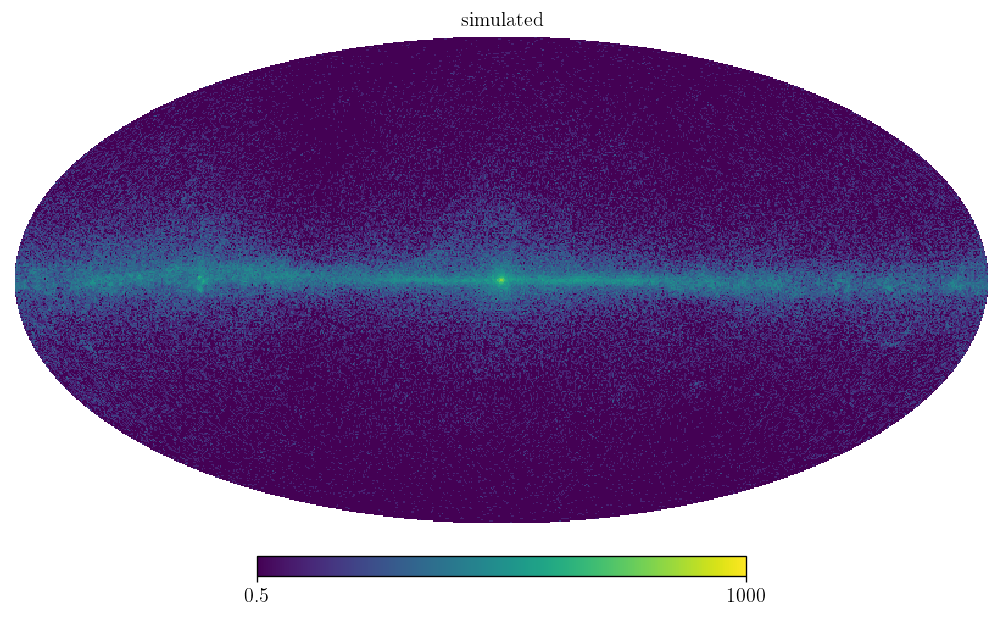

In [ ]:
hp.mollview(jnp.clip(count, 0.5, None), norm='log', max=1000, title='simulated')
plt.show()

## 2. Fit

### 2.1 SVI

In [ ]:
svi_results = npmodel.fit_svi(
    rng_key=jax.random.PRNGKey(4234),
    n_steps=5000,
    guide="iaf",
    lr=5e-5,
    num_particles=8,
    data=jnp.array(counts),
)

100%|██████████| 5000/5000 [22:39<00:00,  3.68it/s, init loss: 82736.0929, avg. loss [4751-5000]: 11952.0951]


In [ ]:
samples = npmodel.get_svi_samples(
    rng_key=jax.random.PRNGKey(42),
    num_samples=50000,
)

In [ ]:
samples = npmodel.expand_samples(samples)

In [ ]:
samples.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF', 'theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF', 'zs'])

In [ ]:
pickle.dump(samples, open(f'../outputs/poisson_sim/test_samples.p', 'wb'))

In [ ]:
from utils.multi_corner import multi_corner

In [ ]:
samples = pickle.load(open('../outputs/poisson_sim/test_samples.p', 'rb'))

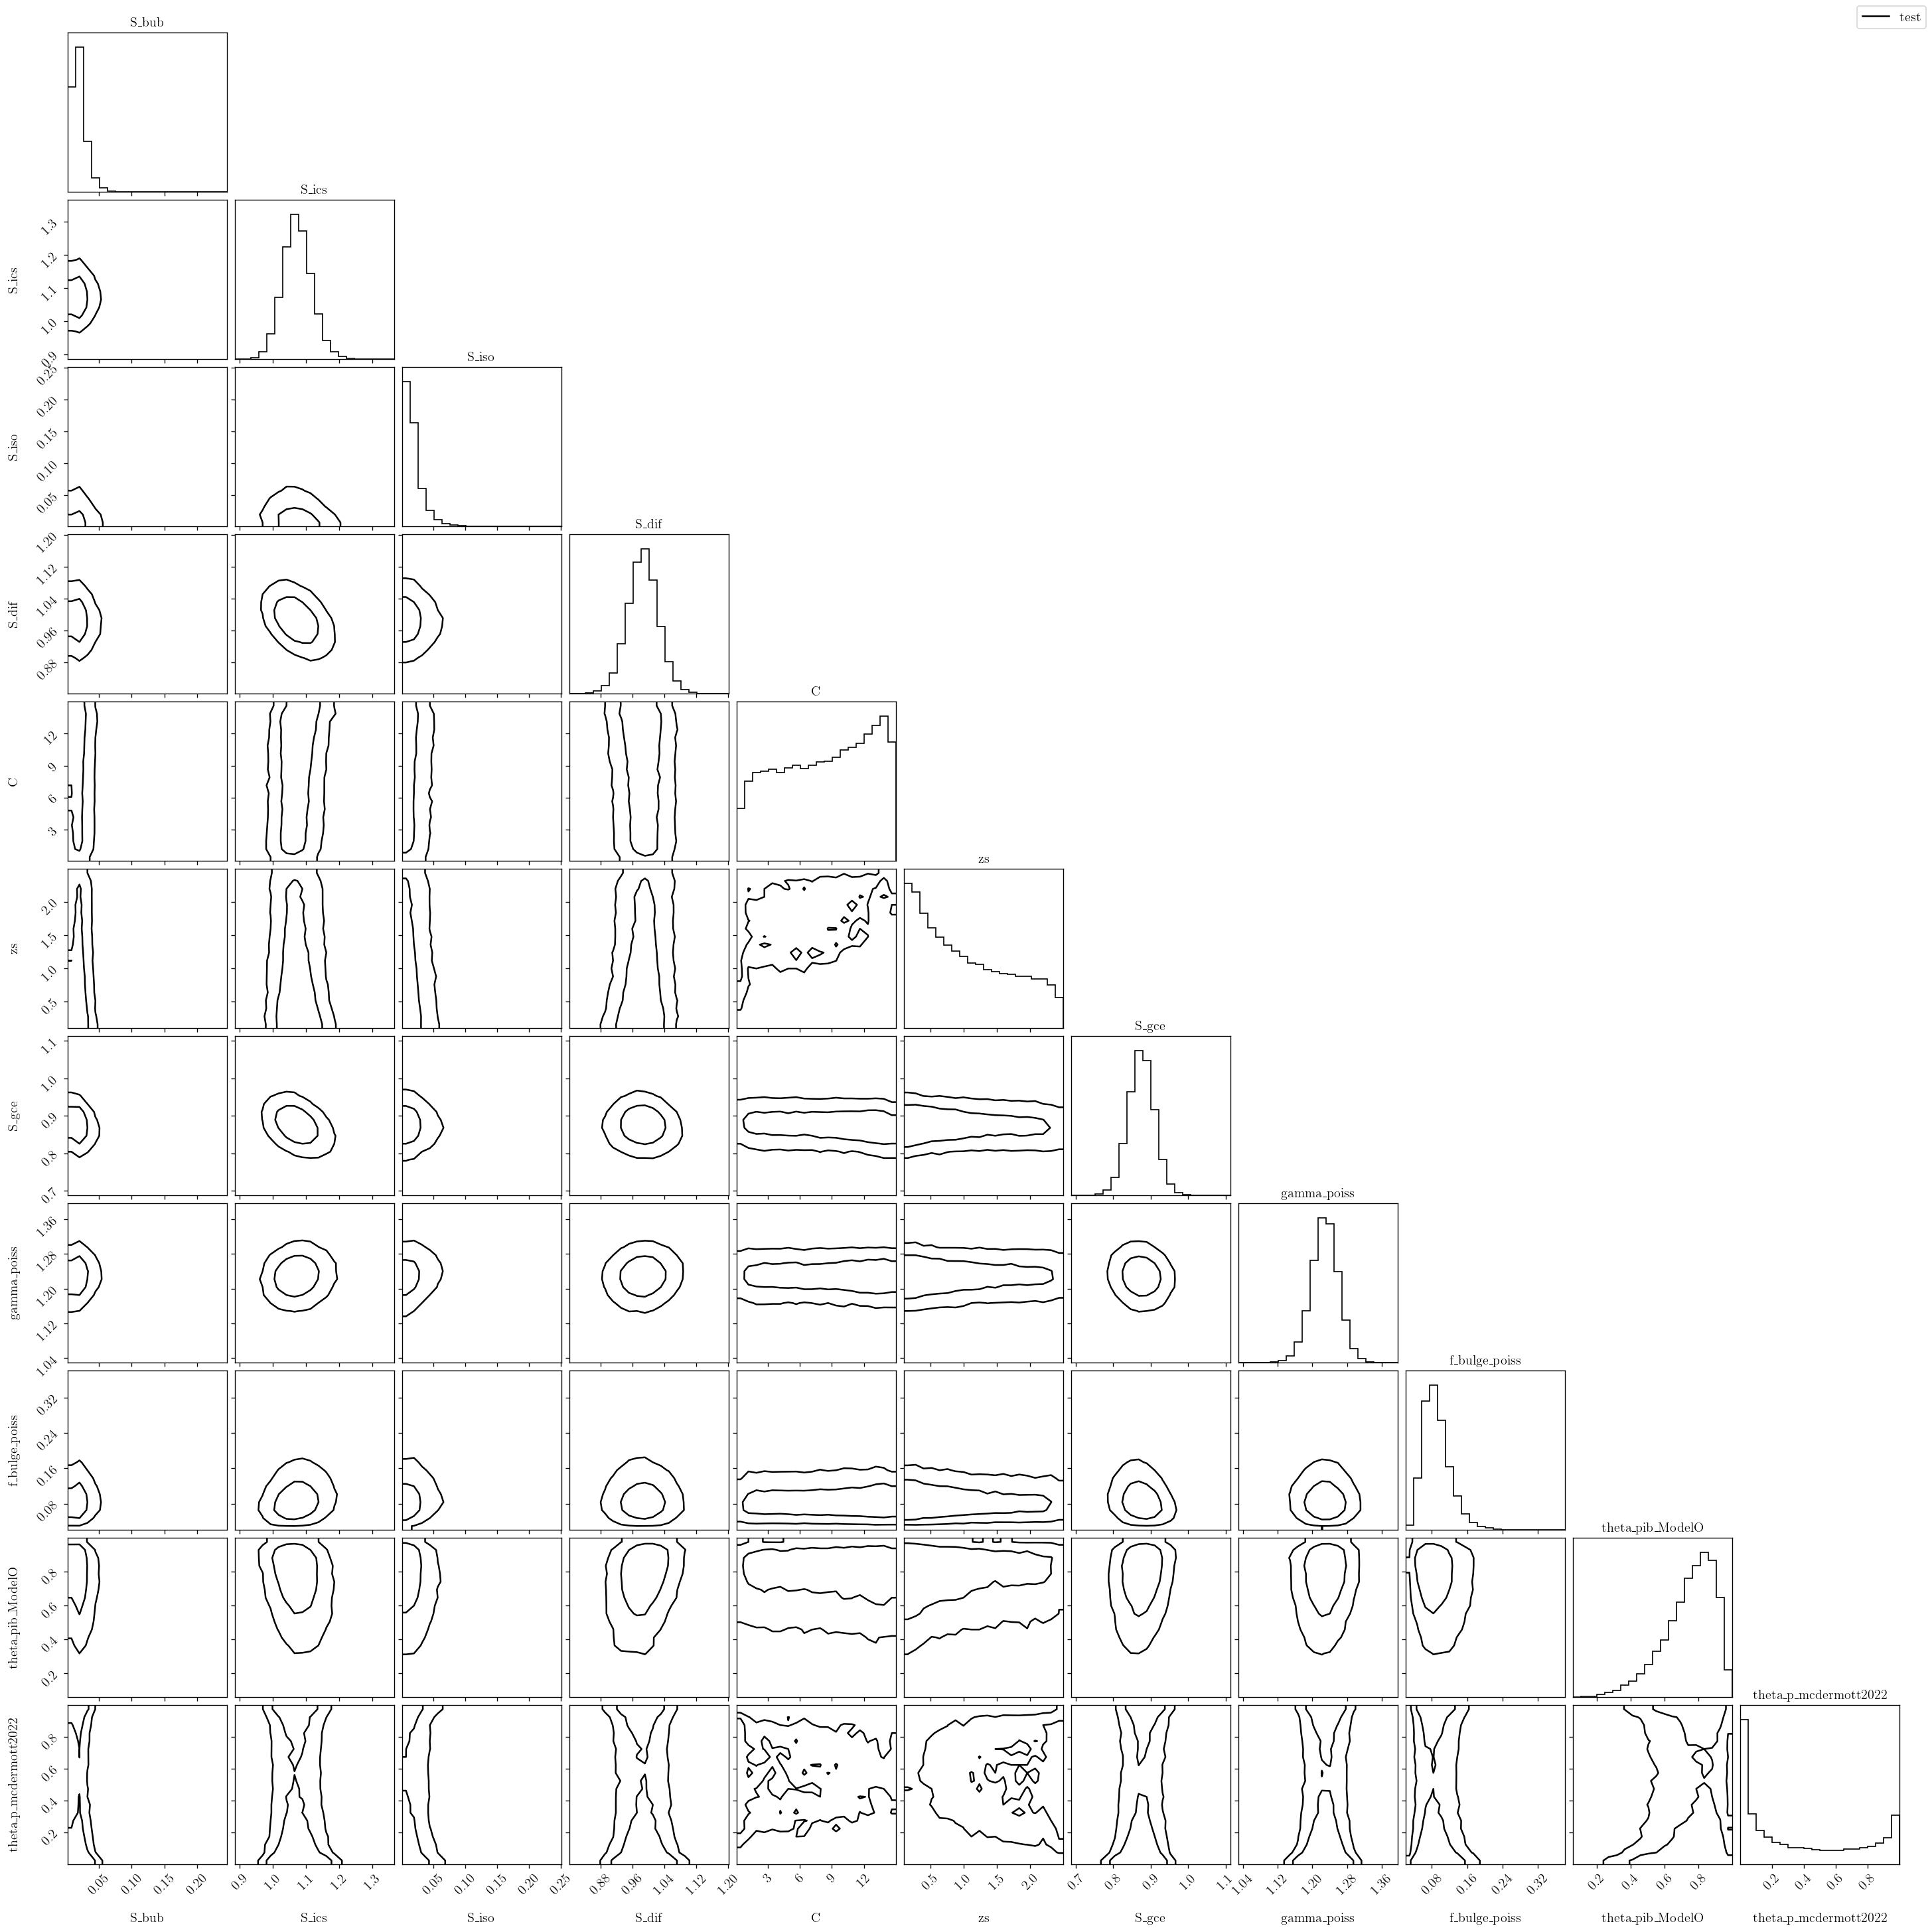

In [ ]:
samples_dict = {
    '' : samples
}
colors_dict = {
    '' : 'k'
}
labels_dict = {
    '' : 'test'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_dif',
    'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_p_mcdermott2022'
]

logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1, save_fn='../outputs/test.pdf'
)

### 2.2 NUTS

In [ ]:
npmodel.run_nuts(num_samples=5000)

In [ ]:
pickle.dump(npmodel.mcmc.get_samples(), open(f'{DATA_DIR}/np_nuts_samples.p', 'wb'))

### 2.3 Parallel tempering

In [ ]:
npmodel.run_parallel_tempering_hmc(
    num_samples=10000,
    num_adaptation_steps=1000,
    step_size_base=3e-2,
)

sample: 100%|█████████████████████████████████████████████████████████████████| 11000/11000 [38:38<00:00,  4.74it/s]


In [ ]:
pickle.dump(npmodel.mcmc.get_samples(), open(f'{DATA_DIR}/np_pthmc_samples.p', 'wb'))

## 3. Compare